
<center><font size=10>Movie Review Sentiment Analysis</center></font>

<center><p float="center">
  <img src="https://i.etsystatic.com/20901364/r/il/899e5a/2416134216/il_570xN.2416134216_hihz.jpg" width=720></a>

## Problem Statement

In the entertainment industry, understanding audience opinions is important for improving movies, marketing strategies, and viewer engagement. However, analyzing a large number of movie reviews manually is time-consuming and difficult. Therefore, this project aims to develop an **AI-based Movie Review Sentiment Analysis system** that automatically analyzes movie reviews and classifies them as **positive or negative**. This helps identify audience opinions efficiently and at scale.


## Objective

The objective of this project is to develop an **AI-based Movie Review Sentiment Analysis system** that uses Natural Language Processing (NLP) and Machine Learning techniques to automatically analyze movie reviews and classify them as **positive or negative**. The system aims to preprocess and transform review text into meaningful numerical representations, train an effective sentiment classification model, and evaluate its performance using suitable metrics. This helps efficiently understand audience opinions and provides useful insights from a large volume of movie reviews.



## **Data Dictionary**

* **review**: Contains the textual review written by a viewer about a movie.
* **sentiment**: Represents the sentiment of the movie review, where **0 indicates a negative review** and **1 indicates a positive review**.


# **Installing and Importing Necessary Libraries**

In [2]:
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2\
             accelerate==1.7.0\
             sentencepiece==0.2.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.1/362.1 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.4 MB/s eta 0:00:00
  Attempting uninstall: sentencepiece
    Found existing installation: sentencepiece 0.2.2
    Uninstalling sentencepiece-0

In [1]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
#import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
#from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# **Importing the dataset**

In [2]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# loading data into a pandas dataframe
reviews = pd.read_csv("/content/drive/MyDrive/Gen AI Dataset/movie_review.csv")

In [4]:
# creating a copy of the data
data = reviews.copy()

# **Data Overview**

## **Checking the first 5 rows**

In [5]:
data.head(5)

,review,sentiment
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",1
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",0
2,"I am a kung fu fan, but not a Woo fan. I have no interest in gangster movies filled with over-the-top gun-play. Now, martial arts; *that's* beautiful! And John Woo surprised me here by producing a highly entertaining kung fu movie, which almost has *too much* fighting, if such a thing is possible! This is good stuff.<br /><br />Many of the fight scenes are very good (and some of them are less good), and the main characters are amusing and likable. The bad guys are a bit too unbelievably evil, but entertaining none the less. You gotta see the Sleeping Wizard!! He can only fight when he's asleep - it's hysterical!<br /><br />Upon repeated viewings, however, Last Hurrah For Chivalry can tend to get a little boring and long-winded, also especially because many of the fight scenes are actually not that good. Hence, I rate it ""only"" a 7 out of 10. But it really is almost an ""8"".<br /><br />All in all one of the better kung fu movies, made smack-dab in the heart of kung fu cinema's prime. All the really good kung fu movies are from the mid- to late 1970ies, with some notable exceptions from the late '60ies and early '70ies (and early '80ies, to be fair).",1
3,"He seems to be a control freak. I have heard him comment on ""losing control of the show"" and tell another guest who brought live animals that he had one rule-""n

* sentiment value of **0 is negative** and **1 is positive**.

## **Checking the shape of the data**

In [6]:
data.shape

(9982, 2)

* The dataset has 10000 rows and 2 columns.

## **Checking for missing values**

In [7]:
data.isnull().sum()

,0
review,0
sentiment,0


* There are no missing values in the data

## **Checking for duplicate values**

In [8]:
# checking for duplicate values
data.duplicated().sum()

0

In [9]:
# keeping only the first occurence of duplicate values and dropping the rest
data = data.drop_duplicates(keep = 'first')

In [10]:
# reseting the index of the dataframe
data = data.reset_index(drop = True)

In [11]:
data

,review,sentiment
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",1
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",0
2,"I am a kung fu fan, but not a Woo fan. I have no interest in gangster movies filled with over-the-top gun-play. Now, martial arts; *that's* beautiful! And John Woo surprised me here by producing a highly entertaining kung fu movie, which almost has *too much* fighting, if such a thing is possible! This is good stuff.<br /><br />Many of the fight scenes are very good (and some of them are less good), and the main characters are amusing and likable. The bad guys are a bit too unbelievably evil, but entertaining none the less. You gotta see the Sleeping Wizard!! He can only fight when he's asleep - it's hysterical!<br /><br />Upon repeated viewings, however, Last Hurrah For Chivalry can tend to get a little boring and long-winded, also especially because many of the fight scenes are actually not that good. Hence, I rate it ""only"" a 7 out of 10. But it really is almost an ""8"".<br /><br />All in all one of the better kung fu movies, made smack-dab in the heart of kung fu cinema's prime. All the really good kung fu movies are from the mid- to late 1970ies, with some notable exceptions from the late '60ies and early '70ies (and early '80ies, to be fair).",1
3,"He seems to be a control freak. I have heard him comment on ""losing control of the show"" and tell another guest who brought live animals that he had one rule-""n

## **Checking the distribution of sentiments**

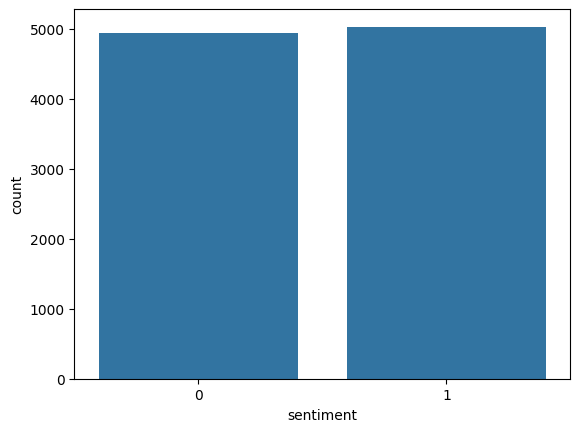

In [12]:
sns.countplot(data=data, x='sentiment');

- There are almost an equal number of positive and negative reviews.

# **Text Embedding and Sentiment Analysis: Word2Vec**

## **Generating Embeddings with Word2Vec**

In [13]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in data['review'].values]

In [14]:
len(words_list)

9982

In [15]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [16]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 157460


### **Basic Examples**

In [17]:
model_W2V.wv["good"]

array([ 1.3534851 ,  0.87200797, -1.0900148 ,  0.5154666 ,  0.2558658 ,
       -2.563561  ,  2.5049536 ,  1.5250696 , -1.6482278 ,  0.321323  ,
        0.58165395,  0.19677417, -0.6359178 ,  0.9054695 , -0.31219113,
        0.39788178,  0.61834645,  0.7325085 , -0.5130389 , -0.43906334,
        0.61120266,  0.74922174, -0.16089353,  0.19612959, -0.6221522 ,
       -0.7834296 , -0.61506295, -1.9707797 , -1.977581  , -2.5447755 ,
        0.28687242, -0.8717975 ,  0.4160901 ,  0.6898767 ,  0.38643372,
       -0.6956461 ,  0.52243197,  0.07166936,  0.6131194 ,  0.6266533 ,
       -0.8313104 , -0.21856207, -0.56752217,  0.26689225,  0.38107172,
       -0.49156278, -1.0042715 ,  1.5973517 ,  1.2781787 ,  0.57919526,
       -0.18106744, -0.0077288 ,  0.65618265, -0.5484149 , -0.51642704,
        0.9310228 ,  2.0687532 , -0.32616404,  1.3559914 , -0.39877343,
       -0.8002115 , -0.09879257, -0.0095416 , -0.37900233,  0.23190741,
       -0.906636  , -1.2670704 ,  0.16864705,  0.9934645 , -0.06

In [18]:
model_W2V.wv["best"]

array([-2.65315592e-01,  3.42330724e-01, -4.03580338e-01,  3.87514055e-01,
        1.42849699e-01, -7.31075287e-01,  9.36293006e-01,  1.09117520e+00,
       -1.59315372e+00,  5.32743752e-01,  9.19069409e-01, -3.55303586e-01,
       -2.36085510e+00,  2.29583549e+00, -5.38265646e-01, -1.14620757e+00,
        1.48037803e+00, -8.05810869e-01, -1.54591426e-01, -2.00123176e-01,
        8.58538806e-01,  9.30076778e-01, -1.00546598e-01, -2.07418039e-01,
        8.54117215e-01, -1.12887204e+00,  2.47299805e-01, -5.84736168e-01,
        4.35143411e-02, -1.40439987e+00,  2.84373969e-01,  3.55170339e-01,
       -9.39797819e-01,  7.62022734e-01,  3.00925583e-01, -9.38504696e-01,
        1.00037313e+00, -1.78089231e-01,  1.06612432e+00, -4.23274398e-01,
       -5.75282514e-01,  1.58336997e-01,  2.10399404e-01,  5.42051911e-01,
        1.05089796e+00, -5.66057026e-01, -1.16851294e+00,  7.82230794e-01,
       -3.31475466e-01,  1.45703697e+00, -7.49207437e-01,  9.04086351e-01,
        1.17050040e+00,  

### **Encoding the dataset**

In [19]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [20]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [21]:
# creating a dataframe of the vectorized documents
df_Word2Vec = pd.DataFrame(data['review'].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Word2Vec.head()

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,0.337308,-0.303142,-0.336801,-0.088718,0.145747,-0.444394,0.362064,0.640471,-0.146489,-0.217949,...,0.260545,0.351921,0.195617,0.194464,0.695884,0.445224,-0.159031,-0.336393,0.302953,-0.390476
1,0.259835,-0.068805,-0.276204,-0.203743,0.129162,-0.455061,0.523512,0.682572,-0.254134,-0.157038,...,0.294495,0.183446,0.135973,0.123347,0.430057,0.419354,-0.150040,-0.305190,0.236541,-0.553458
2,0.436580,-0.069757,-0.333251,-0.041958,0.148068,-0.590813,0.430811,0.780296,-0.310428,-0.122779,...,0.229824,0.206721,0.117175,0.074534,0.492155,0.411082,-0.167671,-0.324715,0.291946,-0.508081
3,0.286470,-0.098736,-0.255027,-0.240144,0.181325,-0.361650,0.591898,0.598021,-0.214808,-0.225152,...,0.351898,0.180118,-0.007716,0.092559,0.457083,0.507784,-0.171596,-0.190956,0.289683,-0.545634
4,0.400815,-0.124154,-0.345639,-0.194146,0.137807,-0.471261,0.609886,0.653839,-0.228156,-0.194280,...,0.348343,0.085890,0.014633,0.064037,0.496152,0.512938,-0.143788,-0.383179,0.296093,-0.461962


## **Sentiment Analysis with Random Forest**

In [22]:
# Define a function to plot the confusion matrix
def plot_confusion_matrix(actual, predicted):
    # Calculate the confusion matrix
    cm = confusion_matrix(actual, predicted)

    # Create a figure for the plot
    plt.figure(figsize = (5, 4))
    # Define labels for the plot axes
    label_list = ['negative', 'positive']
    # Create a heatmap of the confusion matrix
    sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = label_list, yticklabels = label_list)
    # Set the y-axis label
    plt.ylabel('Actual')
    # Set the x-axis label
    plt.xlabel('Predicted')
    # Display the plot
    plt.show()

In [30]:
# Storing independent variable
X = df_Word2Vec.copy()

# Storing target variable
y = data.sentiment

In [31]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [32]:
# Building the model
rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_word2vec.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

### **Checking Training and Test Performance**

In [33]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train)

# Predicting on test data
y_pred_test = rf_word2vec.predict(X_test)

**Confusion Matrix**

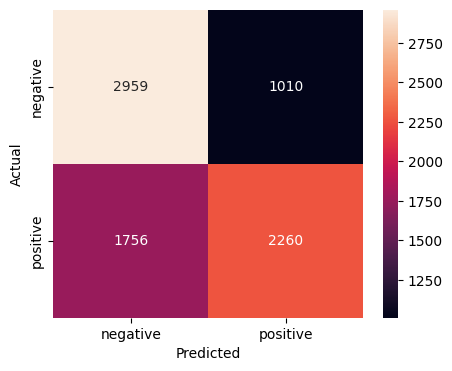

In [34]:
plot_confusion_matrix(y_train, y_pred_train)

Observation

The model correctly classifies most reviews, with better performance for negative sentiment. However, several positive reviews are misclassified as negative, showing room for improvement.

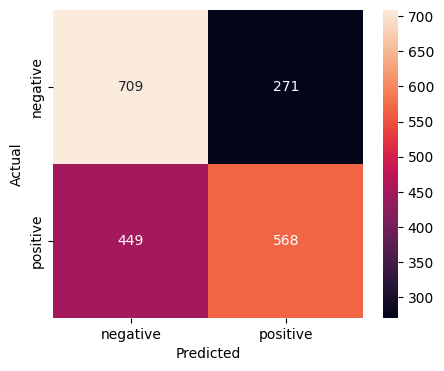

In [35]:
plot_confusion_matrix(y_test, y_pred_test)

The model correctly identifies most negative reviews, while some positive reviews are misclassified as negative. Overall, the model shows reasonable performance.

**Accuracy**

In [36]:
train_accuracy_Word2Vec_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_Word2Vec_RF)
test_accuracy_Word2Vec_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_RF)

The accuracy on the training set is:  0.6536005009392611
The accuracy on the test set is:  0.6394591887831748


## **Sentiment Analysis with Neural Networks**

In [37]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))  # 2 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,914 (183.26 KB)

 Trainable params: 46,914 (183.26 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Fitting the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5959 - loss: 0.6643 - val_accuracy: 0.6114 - val_loss: 0.6432
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6669 - loss: 0.6127 - val_accuracy: 0.6790 - val_loss: 0.5961
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6824 - loss: 0.5914 - val_accuracy: 0.7001 - val_loss: 0.5739
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6974 - loss: 0.5784 - val_accuracy: 0.6995 - val_loss: 0.5638
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7067 - loss: 0.5730 - val_accuracy: 0.7111 - val_loss: 0.5609
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7001 - loss: 0.5748 - val_accuracy: 0.6930 - val_loss: 0.5810
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7036 - loss: 0.5697 - val_accuracy: 0.7171 - val_loss: 0.5548
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7133 - loss: 0.5605 - val_accuracy: 0

### **Checking Training and Test Performance**

In [39]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [40]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


**Confusion Matrix**

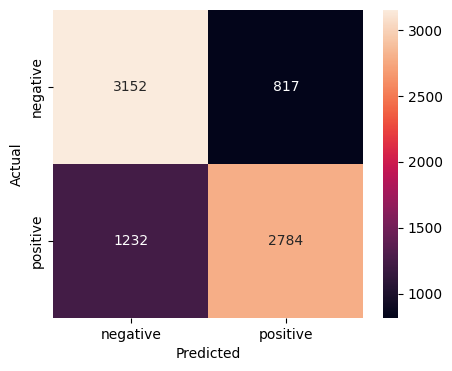

In [41]:
plot_confusion_matrix(y_train, y_train_preds)

The model correctly predicts most negative and positive reviews, showing good overall classification performance. However, some reviews are misclassified between the two classes.

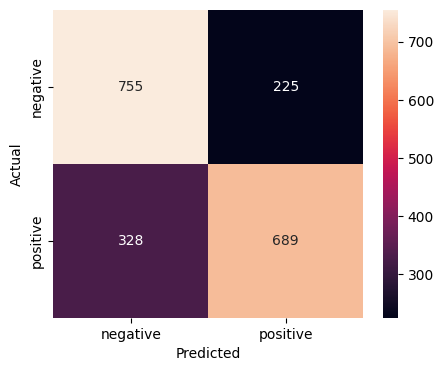

In [42]:
plot_confusion_matrix(y_test, y_test_preds)

The model correctly classifies most negative and positive reviews, with positive reviews showing slightly better prediction. Overall, the model performs well with some misclassifications.

**Accuracy**

In [43]:
train_accuracy_Word2Vec_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the train set is: ",train_accuracy_Word2Vec_NN)
test_accuracy_Word2Vec_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_NN)

The accuracy on the train set is:  0.7433938634940513
The accuracy on the test set is:  0.7230846269404106


# **Text Embedding and Sentiment Analysis: Transformers**

## **Generating Embeddings with Sentence Tranformers**

In [44]:
# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### **Basic Examples**

In [45]:
model.encode(['Hello, my name is Prof. Zena!'])

array([[-1.01322189e-01,  2.77659651e-02, -4.15140949e-02,
         1.84561219e-02, -4.85775061e-02, -1.63206682e-02,
         1.31670862e-01, -2.84867696e-02,  2.94027245e-03,
        -2.18541808e-02, -5.48135825e-02, -9.36222170e-03,
        -1.48072625e-02,  2.78399475e-02, -3.74657512e-02,
        -4.98626439e-04, -6.98262081e-03, -2.66996417e-02,
        -3.89730483e-02, -2.10851245e-02, -9.75726917e-03,
        -1.97301921e-03,  5.53302169e-02, -3.02358232e-02,
        -7.95632601e-02, -1.13197500e-02, -1.35750799e-02,
         1.47868982e-02, -3.55498795e-03, -7.07180873e-02,
         2.56204344e-02,  6.83853552e-02,  2.18798146e-02,
        -1.32919289e-03,  5.71827553e-02,  5.70111871e-02,
        -6.20050877e-02, -1.44120343e-02,  7.99195841e-03,
         7.58275914e-04,  1.20889361e-03,  6.11670362e-03,
        -8.94942135e-02, -3.09457793e-03, -5.15798181e-02,
        -4.05938327e-02,  6.07262887e-02, -1.10701108e-02,
         6.72289655e-02, -3.69399823e-02, -9.92941484e-0

In [46]:
model.encode(['Hello, my name is Professor Zena!'])

array([[-1.11282647e-01,  4.16151881e-02, -4.53359298e-02,
         1.95421670e-02, -6.02430329e-02, -3.59271728e-02,
         9.60513651e-02, -5.55648357e-02,  2.31815130e-02,
        -6.68981858e-03, -2.75410339e-02,  9.78380255e-03,
        -4.83659189e-03,  4.17626016e-02, -5.34442514e-02,
        -3.23484186e-04, -1.19966781e-02, -5.33525459e-02,
        -3.72466482e-02,  5.55621693e-03, -4.23144270e-03,
         2.12437212e-02,  4.35178429e-02, -2.97154039e-02,
        -6.82365745e-02,  1.11056352e-02,  1.19563676e-02,
        -3.14619415e-03, -1.08422600e-02, -6.52326569e-02,
         1.06411846e-02,  6.62760362e-02,  7.96017237e-03,
        -1.82570331e-02,  4.55049612e-02,  3.26332897e-02,
        -3.87101769e-02, -6.36676606e-03,  3.26532796e-02,
        -8.85266624e-03,  2.78331572e-03,  2.53109615e-02,
        -6.47956580e-02, -2.17167344e-02, -5.99524528e-02,
        -2.76416801e-02,  6.41193539e-02, -3.19893770e-02,
         8.19110349e-02, -4.25210707e-02, -7.33608156e-0

### **Encoding the dataset**

In [47]:
# encoding the dataset
embedding_matrix = model.encode(data['review'], show_progress_bar=True)

Batches:   0%|          | 0/312 [00:00<?, ?it/s]

In [48]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(9982, 384)

In [49]:
# printing the embedding vector of the first review in the dataset
embedding_matrix[0,:]

array([-7.45214745e-02,  2.59447796e-03, -3.34989168e-02, -4.84162606e-02,
       -3.84775326e-02,  6.37952685e-02,  5.54270810e-03,  4.06937152e-02,
        6.29823729e-02, -3.84879746e-02, -1.27104744e-02, -2.12660134e-02,
        6.79038912e-02,  2.27345992e-03,  1.14877219e-03,  2.30603553e-02,
        8.18005130e-02,  4.14928868e-02, -2.12946832e-02, -2.29653995e-02,
        2.09020358e-02, -2.93924771e-02,  9.37751532e-02, -2.93005612e-02,
       -6.34454042e-02, -1.70642287e-02,  1.12413354e-01, -2.24412289e-02,
       -6.00713789e-02,  1.55952284e-02,  2.08700951e-02,  7.55285472e-02,
       -6.04214855e-02,  2.33688508e-03, -1.79052651e-02,  7.56648928e-02,
        9.78593621e-03,  2.67771874e-02, -1.30182048e-02, -1.76513437e-02,
        3.84344347e-02,  3.93548124e-02,  5.56519814e-02, -1.35074835e-02,
        5.03627881e-02, -7.22083896e-02, -2.37328708e-02, -1.08479731e-01,
        2.67260894e-02, -5.05364463e-02, -8.09638798e-02,  5.58140166e-02,
       -1.44366117e-03, -

## **Sentiment Analysis with Random Forest**

In [50]:
# Storing independent variable
X = embedding_matrix

# Storing target variable
y = data["sentiment"]

In [51]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
# Building the model
rf_transformer = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

### **Checking Training and Test Performance**

In [53]:
# Predicting on train data
y_pred_train = rf_transformer.predict(X_train)

# Predicting on test data
y_pred_test = rf_transformer.predict(X_test)

**Confusion Matrix**

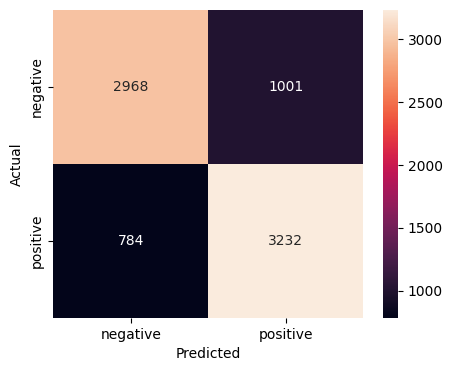

In [54]:
plot_confusion_matrix(y_train, y_pred_train)

The model correctly classifies most negative and positive reviews, with positive reviews showing slightly better prediction. Overall, the model demonstrates good classification performance.

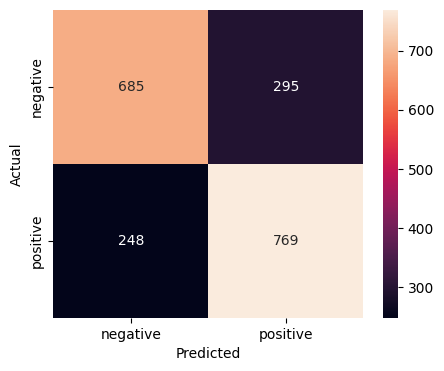

In [55]:
plot_confusion_matrix(y_test, y_pred_test)

The model correctly classifies most positive and negative reviews, with better prediction of positive reviews. Overall, it shows good classification performance.

**Accuracy**

In [56]:
train_accuracy_transformer_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_transformer_RF)
test_accuracy_transformer_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_transformer_RF)

The accuracy on the training set is:  0.7764558547276142
The accuracy on the test set is:  0.728092138207311


## **Sentiment Analysis with Neural Networks**

In [57]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))  # 2 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,666 (225.26 KB)

 Trainable params: 57,666 (225.26 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# Fitting the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
    )

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7483 - loss: 0.5153 - val_accuracy: 0.7867 - val_loss: 0.4367
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8009 - loss: 0.4322 - val_accuracy: 0.7982 - val_loss: 0.4214
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8195 - loss: 0.4026 - val_accuracy: 0.7967 - val_loss: 0.4278
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8321 - loss: 0.3807 - val_accuracy: 0.8047 - val_loss: 0.4187
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8467 - loss: 0.3536 - val_accuracy: 0.7907 - val_loss: 0.4470
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8580 - loss: 0.3275 - val_accuracy: 0.8037 - val_loss: 0.4360
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8739 - loss: 0.2994 - val_accuracy: 0.7947 - val_loss: 0.4434
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8919 - loss: 0.2674 - val_accuracy: 0

### **Checking Training and Test Performance**

In [59]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [60]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


**Confusion Matrix**

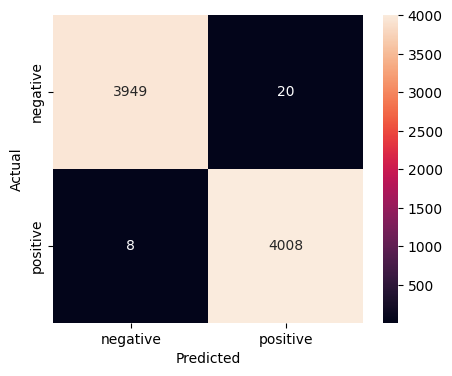

In [61]:
plot_confusion_matrix(y_train, y_train_preds)

The model shows excellent classification performance, correctly predicting almost all negative and positive reviews with very few misclassifications.

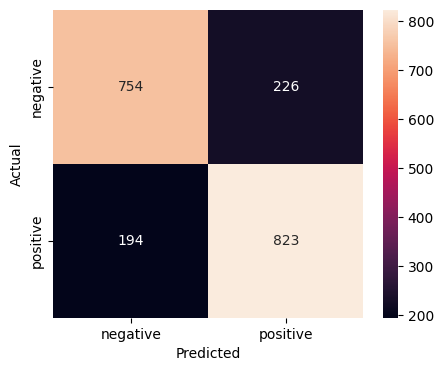

In [62]:
plot_confusion_matrix(y_test, y_test_preds)

The model correctly classifies most positive and negative reviews, with positive reviews predicted slightly better. Overall, it shows good classification performance.

**Accuracy**

In [63]:
train_accuracy_transformer_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the training set is: ",train_accuracy_transformer_NN)
test_accuracy_transformer_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_transformer_NN)

The accuracy on the training set is:  0.9964934251721979
The accuracy on the test set is:  0.7896845267901853


# **Model Perfomance Comparison**

In [64]:
# Create a dictionary to compare different models and their accuracies
model_comp = {
    'Model': [
        'Word2Vec-RF',
        'Sentence-Transformer-RF',
        'Word2Vec-NN',
        'Sentence-Transformer-NN'
    ],
    'Train Accuracy': [
        train_accuracy_Word2Vec_RF,
        train_accuracy_transformer_RF,
        train_accuracy_Word2Vec_NN,
        train_accuracy_transformer_NN
    ],
    'Test Accuracy': [
        test_accuracy_Word2Vec_RF,
        test_accuracy_transformer_RF,
        test_accuracy_Word2Vec_NN,
        test_accuracy_transformer_NN
    ]
}

# Creating the DataFrame
model_comp_df = pd.DataFrame(model_comp)

model_comp_df

,Model,Train Accuracy,Test Accuracy
0,Word2Vec-RF,0.653601,0.639459
1,Sentence-Transformer-RF,0.776456,0.728092
2,Word2Vec-NN,0.743394,0.723085
3,Sentence-Transformer-NN,0.996493,0.789685


<font size=5>Observations</font>



1. **Word2Vec + Random Forest (RF)**
   The model achieved a **training accuracy of 65.36%** and a **test accuracy of 63.95%**. It shows relatively low performance compared with the other models, indicating that Word2Vec embeddings combined with Random Forest were less effective at capturing the sentiment information in the movie reviews.

2. **Sentence-Transformer + Random Forest (RF)**
   This model achieved a **training accuracy of 77.65%** and a **test accuracy of 72.81%**. The improvement over Word2Vec-RF indicates that Sentence-Transformer embeddings capture the contextual meaning of reviews more effectively.

3. **Word2Vec + Neural Network (NN)**
   The model obtained a **training accuracy of 74.34%** and a **test accuracy of 72.31%**. It performed better than Word2Vec-RF and showed only a small difference between training and testing accuracy, suggesting relatively good generalization.

4. **Sentence-Transformer + Neural Network (NN)**
   This model achieved the **highest performance**, with a **training accuracy of 99.65%** and a **test accuracy of 78.97%**. The high test accuracy indicates that it was the best model among the four. However, the large gap between training and test accuracy suggests that the model may be **overfitting** the training data.




# **Conclusion**



The **Movie Review Sentiment Analysis** project successfully developed a system for classifying movie reviews as **positive or negative** using NLP-based text embeddings and machine learning/deep learning models. Word2Vec and Sentence-Transformer embeddings were generated and combined with Random Forest and Neural Network models for performance comparison.


Among the four models, **Sentence-Transformer + Random Forest** was selected as the best-performing model, achieving a **test accuracy of 72.81%**. Its performance shows that Sentence-Transformer embeddings effectively capture the contextual meaning of movie reviews. Overall, the results demonstrate that **Sentence-Transformer embeddings performed better than Word2Vec embeddings** for this movie review sentiment classification task.

